### Projeto Final — Análise do Mercado de Trabalho em Dados
Autores: João, Roberto e Tereza.

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sazidthe1/data-science-salaries")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Casa\.cache\kagglehub\datasets\sazidthe1\data-science-salaries\versions\2


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv(path + '/data_science_salaries.csv')
df.head()

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [15]:
def data_science_salaries_csv(caminho):
    return pd.read_csv(caminho)

In [21]:
# ... (mantendo as funções anteriores)

def vagas_por_cargo(df: pd.DataFrame) -> pd.DataFrame:
    """
    Conta quantos registros existem por cargo (proxy de vagas).
    """
    # Ajustando para garantir que as colunas se chamem 'cargo' e 'qtd_vagas'
    return (
        df["cargo"].value_counts()
          .reset_index()
          .rename(columns={"count": "qtd_vagas"})
    )

# Re-definindo as outras funções para garantir integridade se necessário
def carregar_dados_tratados(caminho_csv: str) -> pd.DataFrame:
    df = pd.read_csv(caminho_csv)
    df = df.rename(columns={
        "job_title": "cargo",
        "experience_level": "nivel_experiencia",
        "employment_type": "tipo_contrato",
        "work_models": "modalidade_trabalho",
        "salary_in_usd": "salario_usd",
        "employee_residence": "pais_residencia",
        "company_location": "pais_empresa",
        "company_size": "porte_empresa",
        "work_year": "ano"
    })
    df["salario_usd"] = pd.to_numeric(df["salario_usd"], errors="coerce")
    df["ano"] = pd.to_numeric(df["ano"], errors="coerce")
    df = df.dropna(subset=["salario_usd", "nivel_experiencia", "cargo"])
    return df

def salario_medio_por_nivel(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula o salário médio por nível de experiência.
    """
    return (
        df.groupby("nivel_experiencia")["salario_usd"]
          .mean()
          .reset_index()
          .sort_values("salario_usd", ascending=False)
    )

def filtrar_por_cargos(df: pd.DataFrame, lista_cargos: list[str]) -> pd.DataFrame:
    return df[df["cargo"].isin(lista_cargos)].copy()

def salario_medio_por_modalidade(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby("modalidade_trabalho")["salario_usd"].mean().reset_index().sort_values("salario_usd", ascending=False)

### Pergunta 1 – Progressão salarial por nível de experiência

Qual é o salário médio em cada nível (EN, MI, SE, EX)? A progressão é parecida entre os cargos principais (Data Analyst, Data Scientist, Data Engineer)?
Queremos entender como o salário médio varia entre os níveis de experiência (EN, MI, SE, EX) e se essa progressão é parecida entre os principais cargos de dados (Data Analyst, Data Scientist, Data Engineer).

In [17]:
# As funções já foram definidas na célula anterior, então não é necessário importar de 'sistema'
caminho = "data_science_salaries.csv"
df = carregar_dados_tratados(caminho)

df.head()

,cargo,nivel_experiencia,tipo_contrato,modalidade_trabalho,ano,pais_residencia,salary,salary_currency,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [24]:
df_salarios = salario_medio_por_nivel(df).round(2)
df_salarios

,nivel_experiencia,salario_usd
1,Executive-level,189687.35
3,Senior-level,162071.06
2,Mid-level,119019.81
0,Entry-level,84448.92


C:\Users\Casa\AppData\Local\Temp\ipykernel_4704\4274999166.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_salarios, x="nivel_experiencia", y="salario_usd", palette="Blues")


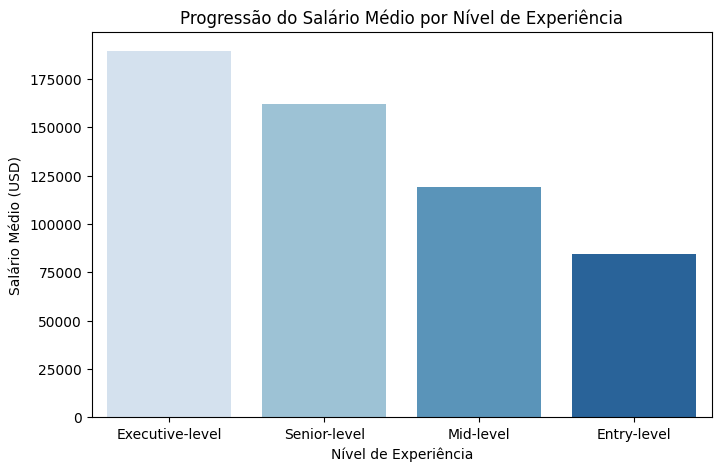

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_salarios, x="nivel_experiencia", y="salario_usd", palette="Blues")
plt.title("Progressão do Salário Médio por Nível de Experiência")
plt.xlabel("Nível de Experiência")
plt.ylabel("Salário Médio (USD)")
plt.show()

Conforme apresentação da média salarial por nível de experiência constata-se que conforme o nivel se eleva o salario cresce tambem.

In [33]:
cargos_principais = [
    "Data Analyst",
    "Data Scientist",
    "Data Engineer"
]

df_cargos = filtrar_por_cargos(df, cargos_principais)

df_cargo_nivel = (
    df_cargos.groupby(["cargo", "nivel_experiencia"])["salario_usd"]
             .mean()
             .reset_index()
)

df_cargo_nivel.round(2)

,cargo,nivel_experiencia,salario_usd
0,Data Analyst,Entry-level,78290.84
1,Data Analyst,Executive-level,114107.14
2,Data Analyst,Mid-level,94854.81
3,Data Analyst,Senior-level,122400.54
4,Data Engineer,Entry-level,79441.09
5,Data Engineer,Executive-level,195357.38
6,Data Engineer,Mid-level,117253.14
7,Data Engineer,Senior-level,156129.57
8,Data Scientist,Entry-level,83387.10
9,Data Scientist,Executive-level,189050.52


In [34]:
ordem_niveis = ["Entry-level", "Mid-level", "Senior-level", "Executive-level"]

df_cargo_nivel["nivel_experiencia"] = pd.Categorical(
    df_cargo_nivel["nivel_experiencia"],
    categories=ordem_niveis,
    ordered=True
)

df_cargo_nivel = df_cargo_nivel.sort_values(["cargo", "nivel_experiencia"]).round(2)
df_cargo_nivel

,cargo,nivel_experiencia,salario_usd
0,Data Analyst,Entry-level,78290.84
2,Data Analyst,Mid-level,94854.81
3,Data Analyst,Senior-level,122400.54
1,Data Analyst,Executive-level,114107.14
4,Data Engineer,Entry-level,79441.09
6,Data Engineer,Mid-level,117253.14
7,Data Engineer,Senior-level,156129.57
5,Data Engineer,Executive-level,195357.38
8,Data Scientist,Entry-level,83387.10
10,Data Scientist,Mid-level,115501.05


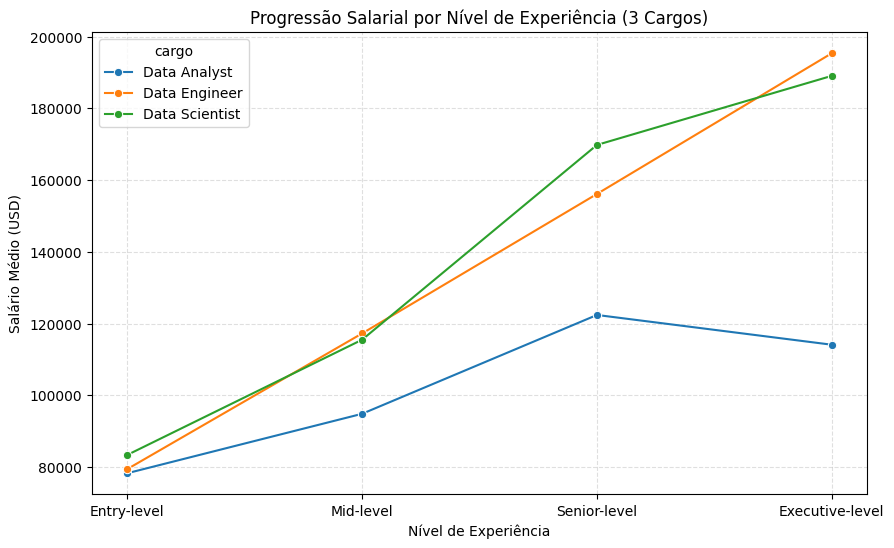

In [38]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_cargo_nivel,
    x="nivel_experiencia",
    y="salario_usd",
    hue="cargo",
    marker="o"
)

plt.title("Progressão Salarial por Nível de Experiência (3 Cargos)")
plt.xlabel("Nível de Experiência")
plt.ylabel("Salário Médio (USD)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

Conforme analise das informações para os cargos de Data Engineer e Data Science os salarios tem a tendencia a se eleveram conforme o nivel de experiencia, porem para o cargo de Data Analiyst esta oredem não ocorreu, visto que a media salario dos empregados do nível sênior é superior ao cargo de executivo.